# TransnetV2

> Shot boundary detection neural net

https://arxiv.org/abs/2008.04838


In [23]:
#| default_exp video.model.transnetv2

In [24]:
#| hide
%load_ext autoreload
%autoreload 2
from nbdev.showdoc import *

## Modules

In [48]:
#| export

# torch
import torch
import torch.nn as nn
import torch.nn.functional as functional

# vision
import torchvision
from torchvision.io import read_video
from torchvision import transforms as tfs
from torchvision.transforms._transforms_video import CenterCropVideo, NormalizeVideo
import av
import pytorchvideo

# math
import random
import numpy as np

# ui
from matplotlib import pyplot as plt
import torchvision.transforms.functional as F


plt.rcParams["savefig.bbox"] = "tight"

In [26]:
#| export

class TransNetV2(nn.Module):

    def __init__(self,
                 F=16, L=3, S=2, D=1024,
                 use_many_hot_targets=True,
                 use_frame_similarity=True,
                 use_color_histograms=True,
                 use_mean_pooling=False,
                 dropout_rate=0.5,
                 use_convex_comb_reg=False,  # not supported
                 use_resnet_features=False,  # not supported
                 use_resnet_like_top=False,  # not supported
                 frame_similarity_on_last_layer=False):  # not supported
        super(TransNetV2, self).__init__()

        if use_resnet_features or use_resnet_like_top or use_convex_comb_reg or frame_similarity_on_last_layer:
            raise NotImplemented("Some options not implemented in Pytorch version of Transnet!")

        self.SDDCNN = nn.ModuleList(
            [StackedDDCNNV2(in_filters=3, n_blocks=S, filters=F, stochastic_depth_drop_prob=0.)] +
            [StackedDDCNNV2(in_filters=(F * 2 ** (i - 1)) * 4, n_blocks=S, filters=F * 2 ** i) for i in range(1, L)]
        )

        self.frame_sim_layer = FrameSimilarity(
            sum([(F * 2 ** i) * 4 for i in range(L)]), lookup_window=101, output_dim=128, similarity_dim=128, use_bias=True
        ) if use_frame_similarity else None
        self.color_hist_layer = ColorHistograms(
            lookup_window=101, output_dim=128
        ) if use_color_histograms else None

        self.dropout = nn.Dropout(dropout_rate) if dropout_rate is not None else None

        output_dim = ((F * 2 ** (L - 1)) * 4) * 3 * 6  # 3x6 for spatial dimensions
        if use_frame_similarity: output_dim += 128
        if use_color_histograms: output_dim += 128

        self.fc1 = nn.Linear(output_dim, D)
        self.cls_layer1 = nn.Linear(D, 1)
        self.cls_layer2 = nn.Linear(D, 1) if use_many_hot_targets else None

        self.use_mean_pooling = use_mean_pooling
        self.eval()

    def forward(self, inputs):
        assert isinstance(inputs, torch.Tensor) and list(inputs.shape[2:]) == [27, 48, 3] and inputs.dtype == torch.uint8, \
            "incorrect input type and/or shape"
        # uint8 of shape [B, T, H, W, 3] to float of shape [B, 3, T, H, W]
        x = inputs.permute([0, 4, 1, 2, 3]).float()
        x = x.div_(255.)

        block_features = []
        for block in self.SDDCNN:
            x = block(x)
            block_features.append(x)

        if self.use_mean_pooling:
            x = torch.mean(x, dim=[3, 4])
            x = x.permute(0, 2, 1)
        else:
            x = x.permute(0, 2, 3, 4, 1)
            x = x.reshape(x.shape[0], x.shape[1], -1)

        if self.frame_sim_layer is not None:
            x = torch.cat([self.frame_sim_layer(block_features), x], 2)

        if self.color_hist_layer is not None:
            x = torch.cat([self.color_hist_layer(inputs), x], 2)

        x = self.fc1(x)
        x = functional.relu(x)

        if self.dropout is not None:
            x = self.dropout(x)

        one_hot = self.cls_layer1(x)

        if self.cls_layer2 is not None:
            return one_hot, {"many_hot": self.cls_layer2(x)}

        return one_hot

In [27]:
#| export

class StackedDDCNNV2(nn.Module):

    def __init__(self,
                 in_filters,
                 n_blocks,
                 filters,
                 shortcut=True,
                 use_octave_conv=False,  # not supported
                 pool_type="avg",
                 stochastic_depth_drop_prob=0.0):
        super(StackedDDCNNV2, self).__init__()

        if use_octave_conv:
            raise NotImplemented("Octave convolution not implemented in Pytorch version of Transnet!")

        assert pool_type == "max" or pool_type == "avg"
        if use_octave_conv and pool_type == "max":
            print("WARN: Octave convolution was designed with average pooling, not max pooling.")

        self.shortcut = shortcut
        self.DDCNN = nn.ModuleList([
            DilatedDCNNV2(in_filters if i == 1 else filters * 4, filters, octave_conv=use_octave_conv,
                          activation=functional.relu if i != n_blocks else None) for i in range(1, n_blocks + 1)
        ])
        self.pool = nn.MaxPool3d(kernel_size=(1, 2, 2)) if pool_type == "max" else nn.AvgPool3d(kernel_size=(1, 2, 2))
        self.stochastic_depth_drop_prob = stochastic_depth_drop_prob

    def forward(self, inputs):
        x = inputs
        shortcut = None

        for block in self.DDCNN:
            x = block(x)
            if shortcut is None:
                shortcut = x

        x = functional.relu(x)

        if self.shortcut is not None:
            if self.stochastic_depth_drop_prob != 0.:
                if self.training:
                    if random.random() < self.stochastic_depth_drop_prob:
                        x = shortcut
                    else:
                        x = x + shortcut
                else:
                    x = (1 - self.stochastic_depth_drop_prob) * x + shortcut
            else:
                x += shortcut

        x = self.pool(x)
        return x


In [28]:
#| export

class DilatedDCNNV2(nn.Module):

    def __init__(self,
                 in_filters,
                 filters,
                 batch_norm=True,
                 activation=None,
                 octave_conv=False):  # not supported
        super(DilatedDCNNV2, self).__init__()

        if octave_conv:
            raise NotImplemented("Octave convolution not implemented in Pytorch version of Transnet!")

        assert not (octave_conv and batch_norm)

        self.Conv3D_1 = Conv3DConfigurable(in_filters, filters, 1, use_bias=not batch_norm)
        self.Conv3D_2 = Conv3DConfigurable(in_filters, filters, 2, use_bias=not batch_norm)
        self.Conv3D_4 = Conv3DConfigurable(in_filters, filters, 4, use_bias=not batch_norm)
        self.Conv3D_8 = Conv3DConfigurable(in_filters, filters, 8, use_bias=not batch_norm)

        self.bn = nn.BatchNorm3d(filters * 4, eps=1e-3) if batch_norm else None
        self.activation = activation

    def forward(self, inputs):
        conv1 = self.Conv3D_1(inputs)
        conv2 = self.Conv3D_2(inputs)
        conv3 = self.Conv3D_4(inputs)
        conv4 = self.Conv3D_8(inputs)

        x = torch.cat([conv1, conv2, conv3, conv4], dim=1)

        if self.bn is not None:
            x = self.bn(x)

        if self.activation is not None:
            x = self.activation(x)

        return x

In [29]:
#| export

class Conv3DConfigurable(nn.Module):

    def __init__(self,
                 in_filters,
                 filters,
                 dilation_rate,
                 separable=True,
                 octave=False,  # not supported
                 use_bias=True,
                 kernel_initializer=None):  # not supported
        super(Conv3DConfigurable, self).__init__()

        if octave:
            raise NotImplemented("Octave convolution not implemented in Pytorch version of Transnet!")
        if kernel_initializer is not None:
            raise NotImplemented("Kernel initializers are not implemented in Pytorch version of Transnet!")

        assert not (separable and octave)

        if separable:
            # (2+1)D convolution https://arxiv.org/pdf/1711.11248.pdf
            conv1 = nn.Conv3d(in_filters, 2 * filters, kernel_size=(1, 3, 3),
                              dilation=(1, 1, 1), padding=(0, 1, 1), bias=False)
            conv2 = nn.Conv3d(2 * filters, filters, kernel_size=(3, 1, 1),
                              dilation=(dilation_rate, 1, 1), padding=(dilation_rate, 0, 0), bias=use_bias)
            self.layers = nn.ModuleList([conv1, conv2])
        else:
            conv = nn.Conv3d(in_filters, filters, kernel_size=3,
                             dilation=(dilation_rate, 1, 1), padding=(dilation_rate, 1, 1), bias=use_bias)
            self.layers = nn.ModuleList([conv])

    def forward(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x


In [30]:
#| export

class FrameSimilarity(nn.Module):

    def __init__(self,
                 in_filters,
                 similarity_dim=128,
                 lookup_window=101,
                 output_dim=128,
                 stop_gradient=False,  # not supported
                 use_bias=False):
        super(FrameSimilarity, self).__init__()

        if stop_gradient:
            raise NotImplemented("Stop gradient not implemented in Pytorch version of Transnet!")

        self.projection = nn.Linear(in_filters, similarity_dim, bias=use_bias)
        self.fc = nn.Linear(lookup_window, output_dim)

        self.lookup_window = lookup_window
        assert lookup_window % 2 == 1, "`lookup_window` must be odd integer"

    def forward(self, inputs):
        x = torch.cat([torch.mean(x, dim=[3, 4]) for x in inputs], dim=1)
        x = torch.transpose(x, 1, 2)

        x = self.projection(x)
        x = functional.normalize(x, p=2, dim=2)

        batch_size, time_window = x.shape[0], x.shape[1]
        similarities = torch.bmm(x, x.transpose(1, 2))  # [batch_size, time_window, time_window]
        similarities_padded = functional.pad(similarities, [(self.lookup_window - 1) // 2, (self.lookup_window - 1) // 2])

        batch_indices = torch.arange(0, batch_size, device=x.device).view([batch_size, 1, 1]).repeat(
            [1, time_window, self.lookup_window])
        time_indices = torch.arange(0, time_window, device=x.device).view([1, time_window, 1]).repeat(
            [batch_size, 1, self.lookup_window])
        lookup_indices = torch.arange(0, self.lookup_window, device=x.device).view([1, 1, self.lookup_window]).repeat(
            [batch_size, time_window, 1]) + time_indices

        similarities = similarities_padded[batch_indices, time_indices, lookup_indices]
        return functional.relu(self.fc(similarities))



In [31]:
#| export

class ColorHistograms(nn.Module):

    def __init__(self,
                 lookup_window=101,
                 output_dim=None):
        super(ColorHistograms, self).__init__()

        self.fc = nn.Linear(lookup_window, output_dim) if output_dim is not None else None
        self.lookup_window = lookup_window
        assert lookup_window % 2 == 1, "`lookup_window` must be odd integer"

    @staticmethod
    def compute_color_histograms(frames):
        frames = frames.int()

        def get_bin(frames):
            # returns 0 .. 511
            R, G, B = frames[:, :, 0], frames[:, :, 1], frames[:, :, 2]
            R, G, B = R >> 5, G >> 5, B >> 5
            return (R << 6) + (G << 3) + B

        batch_size, time_window, height, width, no_channels = frames.shape
        assert no_channels == 3
        frames_flatten = frames.view(batch_size * time_window, height * width, 3)

        binned_values = get_bin(frames_flatten)
        frame_bin_prefix = (torch.arange(0, batch_size * time_window, device=frames.device) << 9).view(-1, 1)
        binned_values = (binned_values + frame_bin_prefix).view(-1)

        histograms = torch.zeros(batch_size * time_window * 512, dtype=torch.int32, device=frames.device)
        histograms.scatter_add_(0, binned_values, torch.ones(len(binned_values), dtype=torch.int32, device=frames.device))

        histograms = histograms.view(batch_size, time_window, 512).float()
        histograms_normalized = functional.normalize(histograms, p=2, dim=2)
        return histograms_normalized

    def forward(self, inputs):
        x = self.compute_color_histograms(inputs)

        batch_size, time_window = x.shape[0], x.shape[1]
        similarities = torch.bmm(x, x.transpose(1, 2))  # [batch_size, time_window, time_window]
        similarities_padded = functional.pad(similarities, [(self.lookup_window - 1) // 2, (self.lookup_window - 1) // 2])

        batch_indices = torch.arange(0, batch_size, device=x.device).view([batch_size, 1, 1]).repeat(
            [1, time_window, self.lookup_window])
        time_indices = torch.arange(0, time_window, device=x.device).view([1, time_window, 1]).repeat(
            [batch_size, 1, self.lookup_window])
        lookup_indices = torch.arange(0, self.lookup_window, device=x.device).view([1, 1, self.lookup_window]).repeat(
            [batch_size, time_window, 1]) + time_indices

        similarities = similarities_padded[batch_indices, time_indices, lookup_indices]

        if self.fc is not None:
            return functional.relu(self.fc(similarities))
        return similarities


## Usage

In [32]:
def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

/Users/syl20/mambaforge/envs/nimrod/lib/python3.11/site-packages/torchvision/io/video.py:161: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


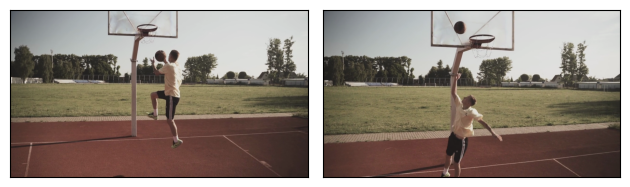

In [33]:
video_path = "../data/video/pexelscom_pavel_danilyuk_basketball_hd.mp4"

frames, _, _ = read_video(str(video_path), output_format="TCHW")

img1_batch = torch.stack([frames[100], frames[150]])
img2_batch = torch.stack([frames[101], frames[151]])

plot(img1_batch)

333 3 720 1280
torch.uint8


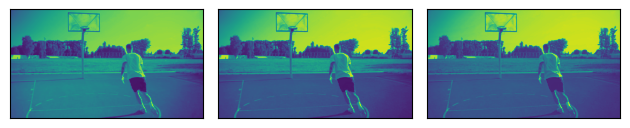

In [43]:
T,C,H,W = frames.shape
print(T,C,H,W)
print(frames[0].dtype)
plot(frames[0])

In [46]:
model = TransNetV2()
state_dict = torch.load("../data/video/models/transnetv2-pytorch-weights.pth")
model.load_state_dict(state_dict)
model.eval()

f = frames.reshape(T,H,W,C).unsqueeze(0)
list(f.shape[2:])
# model(f)



[720, 1280, 3]

In [39]:
with torch.no_grad():
    # shape: batch dim x video frames x frame height x frame width x RGB (not BGR) channels
    # input_video = torch.zeros(1, 100, 27, 48, 3, dtype=torch.uint8)
    single_frame_pred, all_frame_pred = model(f)
    
    single_frame_pred = torch.sigmoid(single_frame_pred).cpu().numpy()
    all_frame_pred = torch.sigmoid(all_frame_pred["many_hot"]).cpu().numpy()

AssertionError: incorrect input type and/or shape

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()